In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from seaborn import set_style

set_style("whitegrid")

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("../data/final_dataframes/main_training_dataframe.csv")

In [ ]:
def all_days_of_year(year):
    start_date = pd.Timestamp(year=year, month=1, day= 1)
    end_date = pd.Timestamp(year=year, month=12, day=31)
    return [x.strftime('%m-%d') for x in pd.date_range(start=start_date, end=end_date, freq= 'd')]
def true_aggregate_per_day(year):
    day_list = all_days_of_year(year)
    df_test = df[df.Year == year]
    aggregates = {}
    for day in day_list:
        df_day = df_test[df_test['MonthDay'] == day]
        aggregates[day] = sum(np.array(df_day.Wind))
    return(aggregates)

In [4]:
def kNN(test_year, df):
    df_train = df[df['Year'] != test_year]
    df_test = df[df['Year'] == test_year]
    features = df.columns.drop(['Unnamed: 0', 'time', 'Year', 'MonthDay', 'Wind']) #extract the features
    days_list = all_days_of_year(test_year)
    no_days = len(days_list)
    pca_comps = [5,6,7,8,9, 10,15,20]
    n_nbrs = [5, 10, 15, 20, 30, 40, 50, 75, 100]
    preds = np.zeros(shape=(len(pca_comps)*len(n_nbrs),no_days))
    dic = {}
    for i in range(len(pca_comps)):
        for j in range(len(n_nbrs)):
            dic[len(n_nbrs)*i + j] = (pca_comps[i], n_nbrs[j])
    for i in range(len(pca_comps)):
        for j in range(len(n_nbrs)):
            pipe = Pipeline([('scale', StandardScaler()), ('pca', PCA(n_components= pca_comps[i]))])
            pipe.fit(df_train[features])

            pca_train = pipe.transform(df_train[features])
            pca_test = pipe.transform(df_test[features])


            knn = KNeighborsRegressor(n_neighbors=n_nbrs[j])
            knn.fit(pca_train, df_train.Wind)

            pred = knn.predict(pca_test)
            preds[len(n_nbrs)*i + j,: ] = [sum(pred[24*i:24*(i+1)]) for i in range(no_days)]
    return pca_comps, n_nbrs, preds, dic

# Without speed cubed

In [5]:
# since wind direction is cylindrical variables, so we convert them to sine and cosine
new_cols = []

for i in range(1, 40):
    dir_col = f'wind_direction_10m_{i}'
    
    sin_col = np.sin(np.deg2rad(df[dir_col]))
    cos_col = np.cos(np.deg2rad(df[dir_col]))
    
    new_cols.append(pd.DataFrame({
        f'{dir_col}_sin': sin_col,
        f'{dir_col}_cos': cos_col
    }))

# Concatenate all new columns at once
df_new = pd.concat([df.drop(columns=[f'wind_direction_10m_{i}' for i in range(1, 40)])] + new_cols, axis=1)

df_without_spd_cubed = df_new.copy()  # defragment

In [6]:
# storing best combinations from each test year, 
# format of dictionary: key = test_year
# value = ((best MAPE pca, best MAPE nbr, MAPE, r2, pred) , (best r2 pca, best r2 nbr, MAPE, r2, pred) )
year_best  = {}
for test_year in [2019,2020,2021,2022]:
    true_aggregates = true_aggregate_per_day(test_year)
    pca_comps, n_nbrs, preds, dic = kNN(test_year,df_without_spd_cubed)
    maes = [mean_absolute_error(y_true= [float(x) for x in true_aggregates.values()], y_pred= preds[i]) 
            for i in range(len(pca_comps)*len(n_nbrs))]
    mapes = [mean_absolute_percentage_error(y_true= [float(x) for x in true_aggregates.values()], 
                                            y_pred= preds[i]) for i in range(len(pca_comps)*len(n_nbrs))]
    r2s = [r2_score(y_true= [float(x) for x in true_aggregates.values()], y_pred= preds[i]) 
           for i in range(len(pca_comps)*len(n_nbrs))]
    best_MAPE_idx = mapes.index(min(mapes))
    best_r2_idx = r2s.index(max(r2s))
    year_best[test_year] = ((dic[best_MAPE_idx][0], dic[best_MAPE_idx][1], min(mapes)*100 , r2s[best_MAPE_idx], preds[best_MAPE_idx]), 
                            (dic[best_r2_idx][0], dic[best_r2_idx][0], mapes[best_r2_idx]*100, max(r2s), preds[best_r2_idx]))
    print(f"TEST YEAR: {test_year}")
    print(f"Best combination in terms of MAPE: pca_comp = {dic[best_MAPE_idx][0]}, no of knn nbrs = {dic[best_MAPE_idx][1]}, MAPE {min(mapes)*100:.1f}%, R_2 score = {r2s[best_MAPE_idx]:.3f}, MAE = {maes[best_MAPE_idx]:.1f}")
    print(f"Best combination in terms of r_2: pca_comp = {dic[best_r2_idx][0]}, no of knn nbrs = {dic[best_r2_idx][1]}, MAPE {mapes[best_r2_idx]*100:.1f}%, R_2 score = {max(r2s):.3f}, MAE = {maes[best_r2_idx]:.1f}\n\n")

TEST YEAR: 2019
Best combination in terms of MAPE: pca_comp = 10, no of knn nbrs = 5, MAPE 16.2%, R_2 score = 0.899, MAE = 4294.2
Best combination in terms of r_2: pca_comp = 15, no of knn nbrs = 10, MAPE 16.8%, R_2 score = 0.905, MAE = 4236.0


TEST YEAR: 2020
Best combination in terms of MAPE: pca_comp = 6, no of knn nbrs = 5, MAPE 23.7%, R_2 score = 0.880, MAE = 4847.5
Best combination in terms of r_2: pca_comp = 10, no of knn nbrs = 10, MAPE 24.9%, R_2 score = 0.883, MAE = 4846.5


TEST YEAR: 2021
Best combination in terms of MAPE: pca_comp = 7, no of knn nbrs = 5, MAPE 24.2%, R_2 score = 0.914, MAE = 3699.1
Best combination in terms of r_2: pca_comp = 10, no of knn nbrs = 10, MAPE 26.4%, R_2 score = 0.919, MAE = 3617.1


TEST YEAR: 2022
Best combination in terms of MAPE: pca_comp = 6, no of knn nbrs = 5, MAPE 19.5%, R_2 score = 0.873, MAE = 4020.6
Best combination in terms of r_2: pca_comp = 10, no of knn nbrs = 50, MAPE 21.6%, R_2 score = 0.887, MAE = 3911.9




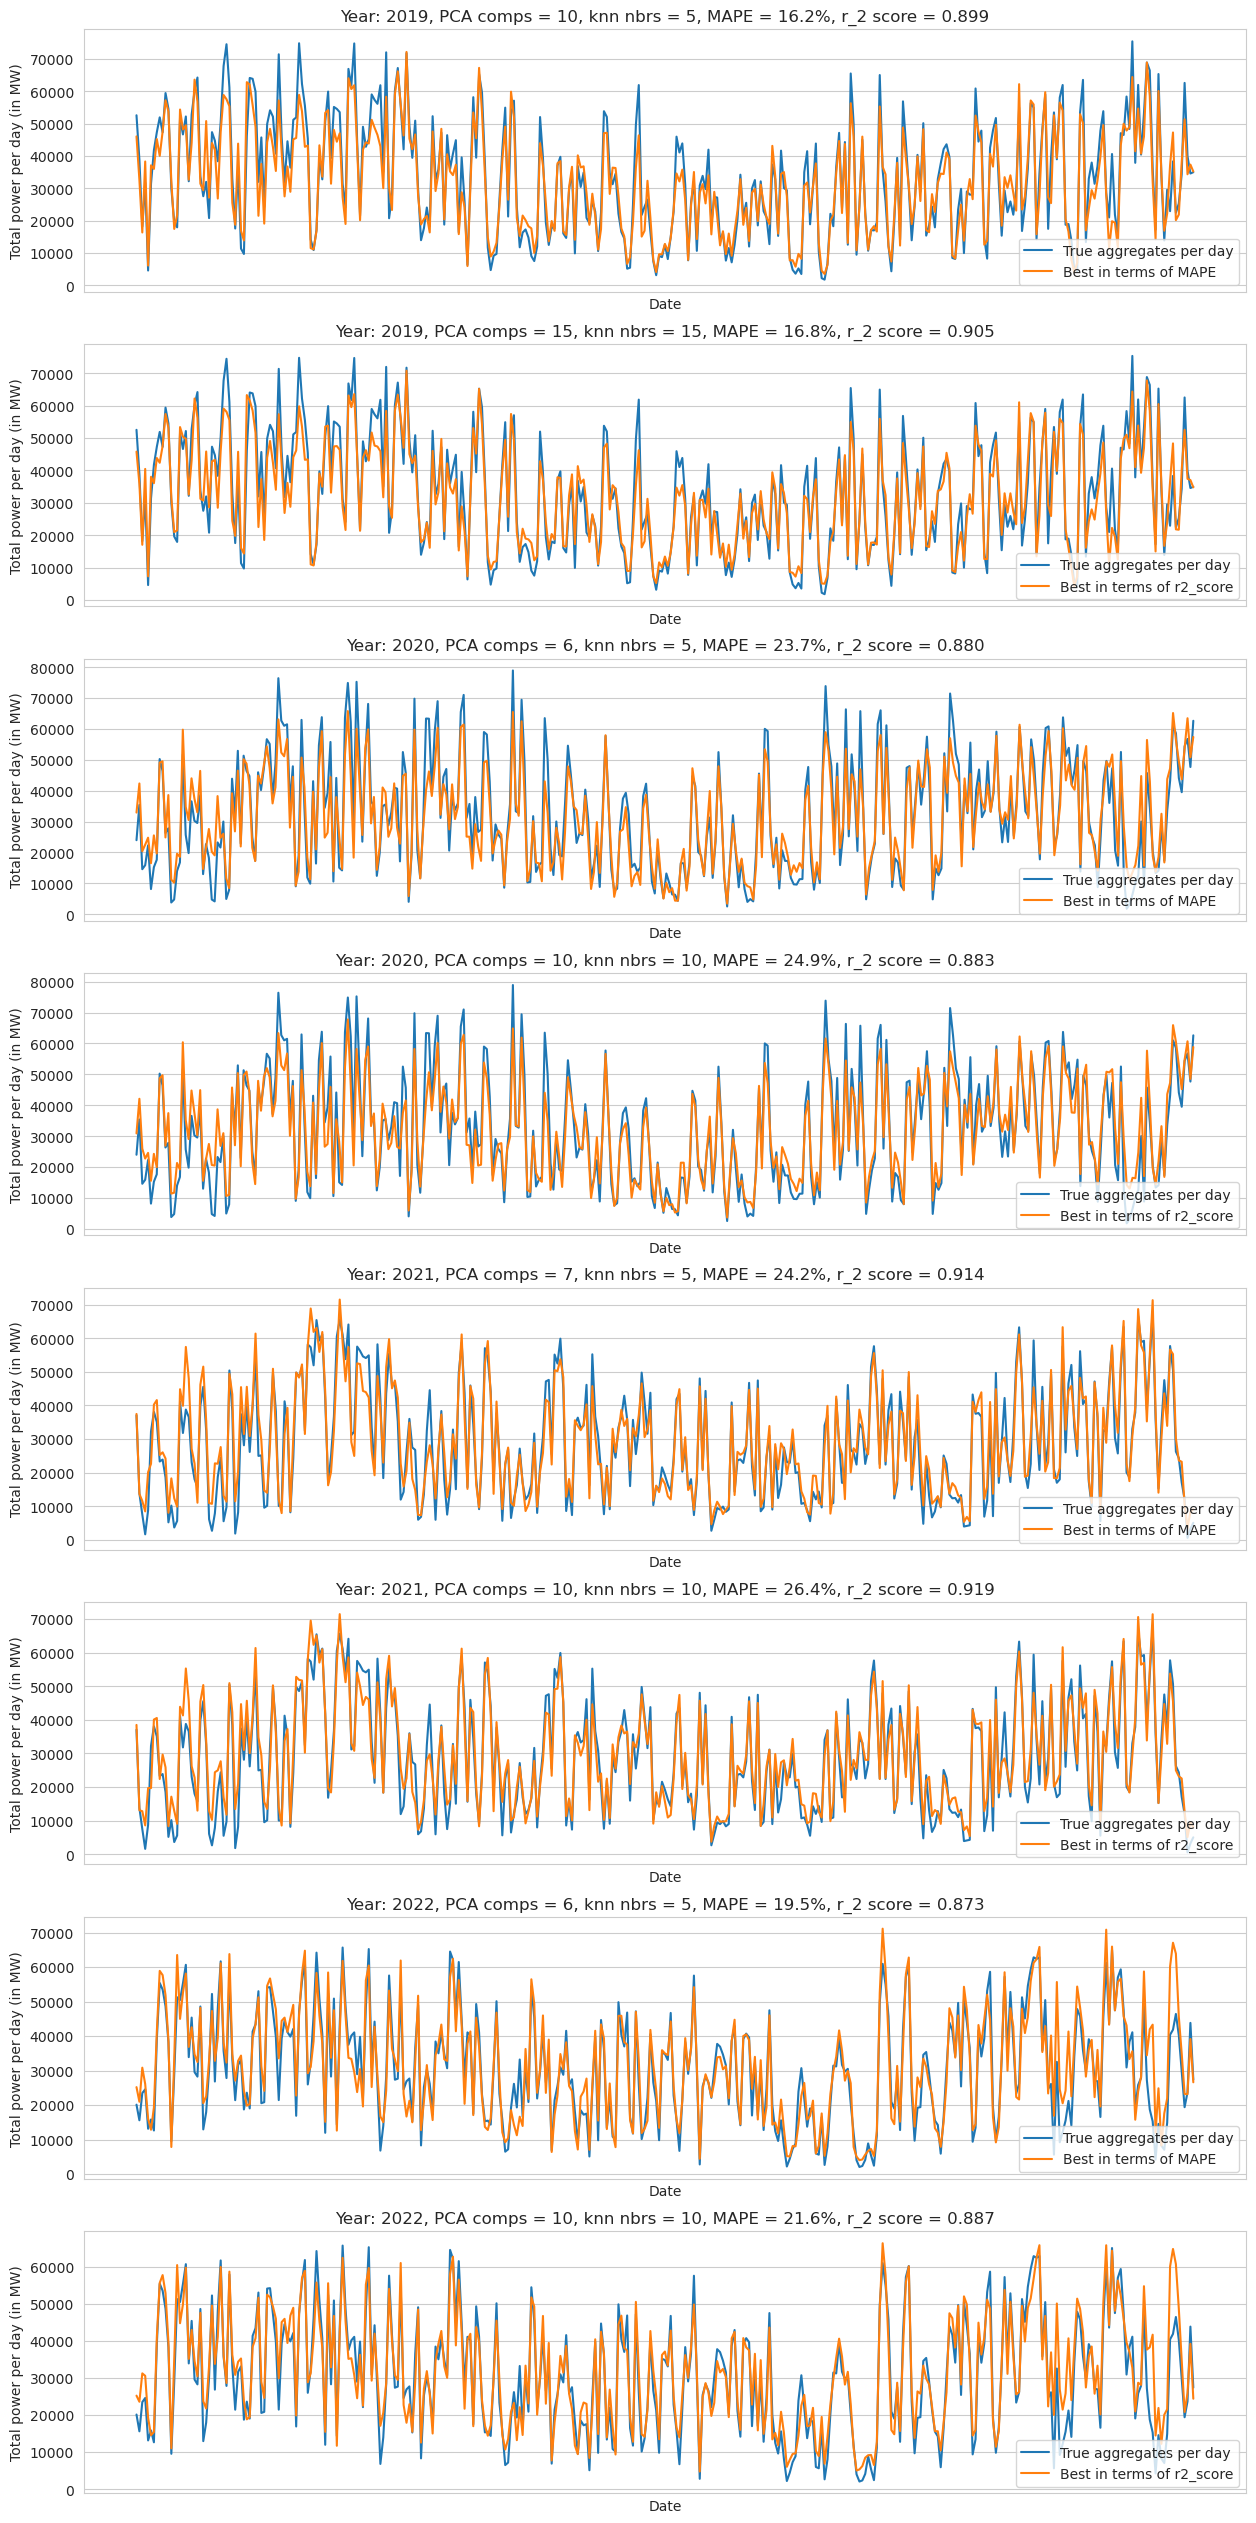

In [26]:
fig, ax = plt.subplots(4*2, 1, figsize=(15, 8*4))

for i, test_year in enumerate([2019,2020,2021,2022]):
    #(best MAPE pca, best MAPE nbr, MAPE, r2, pred)
    days_list = all_days_of_year(test_year)
    true_aggregates = true_aggregate_per_day(test_year)
    ax[2*i].plot(days_list, true_aggregates.values(), label = 'True aggregates per day')
    ax[2*i+1].plot(days_list, true_aggregates.values(), label = 'True aggregates per day') 
    best_MAPE_pca, best_MAPE_nbr, best_MAPE_mape, best_MAPE_r2, best_MAPE_pred = year_best[test_year][0]
    best_r2_pca, best_r2_nbr, best_r2_mape, best_r2_r2, best_r2_pred = year_best[test_year][1]
    ax[2*i].plot(days_list, best_MAPE_pred, label = 'Best in terms of MAPE')
    ax[2*i].set_title(f"Year: {test_year}, PCA comps = {best_MAPE_pca}, knn nbrs = {best_MAPE_nbr}, MAPE = {best_MAPE_mape:.1f}%, r_2 score = {best_MAPE_r2:.3f}")

    ax[2*i+1].plot(days_list, best_r2_pred, label = 'Best in terms of r2_score')
    ax[2*i+1].set_title(f"Year: {test_year}, PCA comps = {best_r2_pca}, knn nbrs = {best_r2_nbr}, MAPE = {best_r2_mape:.1f}%, r_2 score = {best_r2_r2:.3f}")



for i in range(8):
    ax[i].legend(loc='lower right')
    ax[i].tick_params(axis='x', rotation = 45)
    ax[i].set_xticks([])
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Total power per day (in MW)')

plt.show()

# With speed cubed

In [7]:
# since theoretically the wind power depends on speed cubed, so we modify the columns as well
new_cols = []

for i in range(1, 40):
    spd_col = f'wind_speed_10m_{i}'
    cube_col = df[spd_col] ** 3
    
    new_cols.append(pd.DataFrame({
        f'{spd_col}_cubed': cube_col
    }))

# Concatenate all new columns at once
df_new = pd.concat([df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)])] + new_cols, axis=1)

df_speed_cubed = df_new.copy()  # defragment

In [8]:
# storing best combinations from each test year, 
# format of dictionary: key = test_year
# value = ((best MAPE pca, best MAPE nbr, MAPE, r2, pred) , (best r2 pca, best r2 nbr, MAPE, r2, pred) )
year_best_with_spd_cubed  = {}
for test_year in [2019,2020,2021,2022]:
    true_aggregates = true_aggregate_per_day(test_year)
    pca_comps, n_nbrs, preds, dic = kNN(test_year,df_speed_cubed)
    maes = [mean_absolute_error(y_true= [float(x) for x in true_aggregates.values()], y_pred= preds[i]) 
            for i in range(len(pca_comps)*len(n_nbrs))]
    mapes = [mean_absolute_percentage_error(y_true= [float(x) for x in true_aggregates.values()], 
                                            y_pred= preds[i]) for i in range(len(pca_comps)*len(n_nbrs))]
    r2s = [r2_score(y_true= [float(x) for x in true_aggregates.values()], y_pred= preds[i]) 
           for i in range(len(pca_comps)*len(n_nbrs))]
    best_MAPE_idx = mapes.index(min(mapes))
    best_r2_idx = r2s.index(max(r2s))
    year_best_with_spd_cubed[test_year] = ((dic[best_MAPE_idx][0], dic[best_MAPE_idx][1], min(mapes)*100 , r2s[best_MAPE_idx], preds[best_MAPE_idx]), 
                            (dic[best_r2_idx][0], dic[best_r2_idx][0], mapes[best_r2_idx]*100, max(r2s), preds[best_r2_idx]))
    print(f"TEST YEAR: {test_year}")
    print(f"Best combination in terms of MAPE: pca_comp = {dic[best_MAPE_idx][0]}, no of knn nbrs = {dic[best_MAPE_idx][1]}, MAPE {min(mapes)*100:.1f}%, R_2 score = {r2s[best_MAPE_idx]:.3f}, MAE = {maes[best_MAPE_idx]:.1f}")
    print(f"Best combination in terms of r_2: pca_comp = {dic[best_r2_idx][0]}, no of knn nbrs = {dic[best_r2_idx][1]}, MAPE {mapes[best_r2_idx]*100:.1f}%, R_2 score = {max(r2s):.3f}, MAE = {maes[best_r2_idx]:.1f}\n\n")

TEST YEAR: 2019
Best combination in terms of MAPE: pca_comp = 6, no of knn nbrs = 5, MAPE 20.5%, R_2 score = 0.885, MAE = 4714.7
Best combination in terms of r_2: pca_comp = 6, no of knn nbrs = 10, MAPE 21.3%, R_2 score = 0.885, MAE = 4791.2


TEST YEAR: 2020
Best combination in terms of MAPE: pca_comp = 6, no of knn nbrs = 5, MAPE 26.9%, R_2 score = 0.864, MAE = 5212.3
Best combination in terms of r_2: pca_comp = 7, no of knn nbrs = 5, MAPE 27.4%, R_2 score = 0.870, MAE = 5164.7


TEST YEAR: 2021
Best combination in terms of MAPE: pca_comp = 6, no of knn nbrs = 5, MAPE 34.1%, R_2 score = 0.886, MAE = 4342.6
Best combination in terms of r_2: pca_comp = 6, no of knn nbrs = 5, MAPE 34.1%, R_2 score = 0.886, MAE = 4342.6


TEST YEAR: 2022
Best combination in terms of MAPE: pca_comp = 6, no of knn nbrs = 5, MAPE 23.8%, R_2 score = 0.861, MAE = 4396.6
Best combination in terms of r_2: pca_comp = 10, no of knn nbrs = 15, MAPE 26.7%, R_2 score = 0.868, MAE = 4390.0




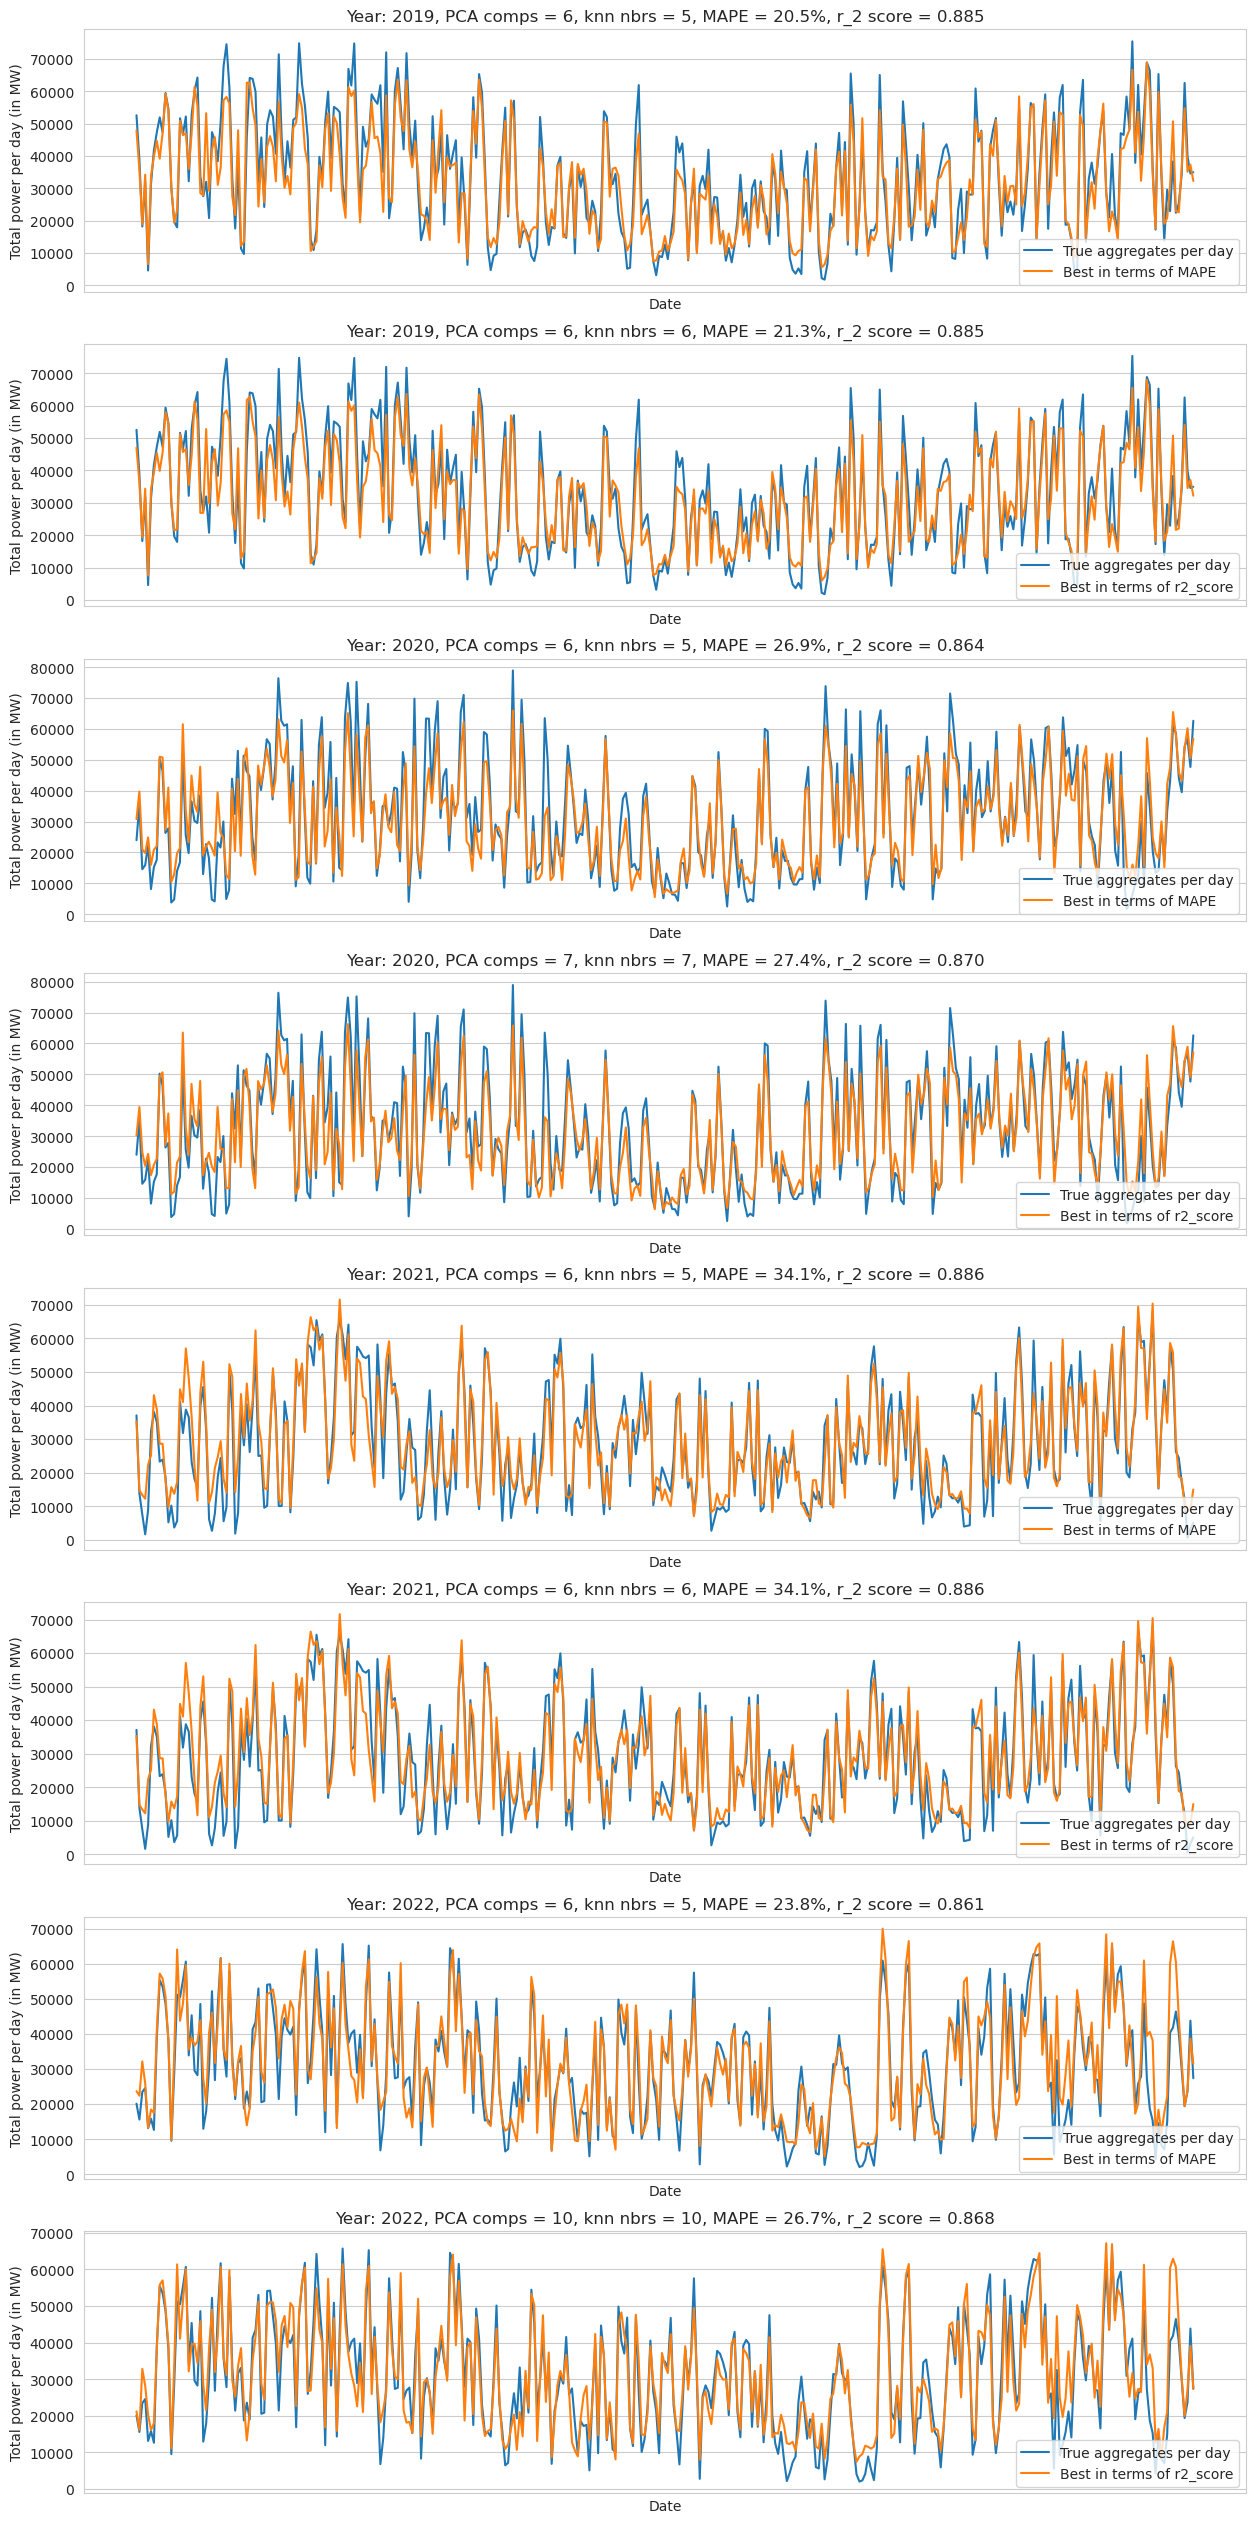

In [25]:
fig, ax = plt.subplots(4*2, 1, figsize=(15, 8*4))

for i, test_year in enumerate([2019,2020,2021,2022]):
    #(best MAPE pca, best MAPE nbr, MAPE, r2, pred)
    days_list = all_days_of_year(test_year)
    true_aggregates = true_aggregate_per_day(test_year)
    ax[2*i].plot(days_list, true_aggregates.values(), label = 'True aggregates per day')
    ax[2*i+1].plot(days_list, true_aggregates.values(), label = 'True aggregates per day') 
    best_MAPE_pca, best_MAPE_nbr, best_MAPE_mape, best_MAPE_r2, best_MAPE_pred = year_best_with_spd_cubed[test_year][0]
    best_r2_pca, best_r2_nbr, best_r2_mape, best_r2_r2, best_r2_pred = year_best_with_spd_cubed[test_year][1]
    ax[2*i].plot(days_list, best_MAPE_pred, label = 'Best in terms of MAPE')
    ax[2*i].set_title(f"Year: {test_year}, PCA comps = {best_MAPE_pca}, knn nbrs = {best_MAPE_nbr}, MAPE = {best_MAPE_mape:.1f}%, r_2 score = {best_MAPE_r2:.3f}")

    ax[2*i+1].plot(days_list, best_r2_pred, label = 'Best in terms of r2_score')
    ax[2*i+1].set_title(f"Year: {test_year}, PCA comps = {best_r2_pca}, knn nbrs = {best_r2_nbr}, MAPE = {best_r2_mape:.1f}%, r_2 score = {best_r2_r2:.3f}")


for i in range(8):
    ax[i].legend(loc='lower right')
    ax[i].tick_params(axis='x', rotation = 45)
    ax[i].set_xticks([])
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Total power per day (in MW)')

plt.show()